In [70]:
### Build A Basic Chatbot

In [71]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages
from typing import Annotated

In [72]:
class State(TypedDict):
    messages:Annotated[list,add_messages]

In [73]:
import os 
from dotenv import load_dotenv
load_dotenv()

True

In [74]:
from langchain_groq import ChatGroq

llm=ChatGroq(model="qwen/qwen3-32b")
llm

ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 16384, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x00000258A47BB2F0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000258A47B8260>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [75]:
def chatbot(state:State):
    return {"messages":llm.invoke(state["messages"])}

In [76]:
graph_builder=StateGraph(State) 
graph_builder.add_node("chatbot",chatbot)
graph_builder.add_edge(START,"chatbot")
graph_builder.add_edge("chatbot",END)
graph=graph_builder.compile()

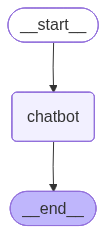

In [77]:
from IPython.display import Image,display
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass


In [78]:
response=graph.invoke({"messages":"hii"})
response["messages"][-1].content

"<think>\nAlright, the user sent a simple greeting. I should respond warmly and open up a conversation. Let me make sure to keep it friendly and inviting. Maybe ask how they're doing today? That should encourage them to share more. I need to keep it natural and not too formal. Just a casual, approachable reply.\n</think>\n\nHello! How can I assist you today? 😊"

##ChatBot with Tools


In [79]:
from langchain_tavily  import TavilySearch

tool= TavilySearch(max_results=2)
tool.invoke("who is vaibhav singh")

{'query': 'who is vaibhav singh',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://en.wikipedia.org/wiki/Vaibhav_Singh_Yadav',
   'title': 'Vaibhav Singh Yadav - Wikipedia',
   'content': '# Vaibhav Singh Yadav. | Vaibhav Singh Yadav at Pattaya in 2019 | |. | Weight\xa0class "Weight class (boxing)") | Welterweight |. **Vaibhav Singh Yadav** (also known as **Ahir Boxer** ) is an Indian boxer from New Delhi. He became World Boxing Council (WBC) Asia silver welterweight champion after defeating Thailand\'s Fahpetch Singmanassak in 2019. Yadav is the first Indian unified titles champion holder. He won this title after defeating Thailand\'s boxer Phongsathon Sompol by a 3rd-round knockout. He won his American debut against William Parra Smith. He trains out of the Nonantum Boxing Club in Newton, MA and resides in Delhi, India. ### Performance in Pro Boxing. ### Total Numbers of Pro Fights. In 2022 Vaibhav Singh Yadav was signed by LFG Boxing Manage

In [80]:
def multiply(a:int,b:int)->int:
     """Calculates the gross salary including bonuses."""
     return a*b

In [81]:
tools=[tool,multiply]
llm_bind_with_tools=llm.bind_tools(tools)


In [82]:
def llm_tool_call(state:State):
    return {"messages":llm_bind_with_tools.invoke(state["messages"])}

In [83]:
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode,tools_condition

graph_builder=StateGraph(State)

graph_builder.add_node("llm_tool_call",llm_tool_call)
graph_builder.add_node("tools",ToolNode(tools))

graph_builder.add_edge(START,"llm_tool_call")
graph_builder.add_conditional_edges("llm_tool_call",tools_condition)
graph_builder.add_edge("tools",END)

graph=graph_builder.compile()




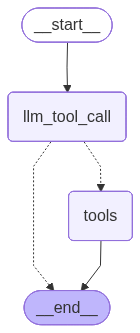

In [84]:
from IPython.display import display,Image

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [85]:
response=graph.invoke({"messages":"what is india smallest distrct and what will be output of 15 * 15"})


KeyboardInterrupt: 

ReAct Architecture

In [ ]:
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode,tools_condition

graph_builder=StateGraph(State)

graph_builder.add_node("llm_tool_call",llm_tool_call)
graph_builder.add_node("tools",ToolNode(tools))

graph_builder.add_edge(START,"llm_tool_call")
graph_builder.add_conditional_edges("llm_tool_call",tools_condition)
graph_builder.add_edge("tools","llm_tool_call")
graph =graph_builder.compile()

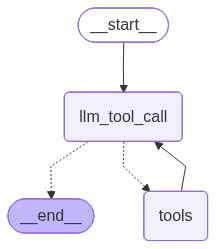

In [ ]:
from IPython.display import display,Image

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

Memory saver Checkpoint

In [ ]:
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode,tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory=MemorySaver()

graph_builder=StateGraph(State)

graph_builder.add_node("llm_tool_call",llm_tool_call)
graph_builder.add_node("tools",ToolNode(tools))

graph_builder.add_edge(START,"llm_tool_call")
graph_builder.add_conditional_edges("llm_tool_call",tools_condition)
graph_builder.add_edge("tools","llm_tool_call")
graph =graph_builder.compile(checkpointer=memory)



In [ ]:
config={"configurable":{"thread_id":"1"}}
response=graph.invoke({"messages":"hii my name is vaibhav"},config=config)
response["messages"][-1]


AIMessage(content="Hello again, Vaibhav! 😊 It's nice to see you. How can I assist you today? Feel free to ask any questions or share what's on your mind!", additional_kwargs={'reasoning_content': 'Okay, Vaibhav greeted me again. Let me check the history. The previous message was "hii my name is vaibhav" and my response was a friendly greeting. Now he\'s sending the same message again. Maybe he\'s testing if I\'m responsive or wants to continue the conversation. I should acknowledge his message again but prompt him to ask a question or share what he needs help with. Keep it friendly and encouraging.\n'}, response_metadata={'token_usage': {'completion_tokens': 133, 'prompt_tokens': 1812, 'total_tokens': 1945, 'completion_time': 0.2463529, 'completion_tokens_details': {'reasoning_tokens': 90}, 'prompt_time': 0.080909889, 'prompt_tokens_details': None, 'queue_time': 0.055261898, 'total_time': 0.327262789}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_5cf921caa2', 'service_tier

In [ ]:
response=graph.invoke({"messages":"hii what is my name"},config=config)
response["messages"][-1]


AIMessage(content='Your name is **Vaibhav**! 😊 You mentioned it earlier. How else can I assist you today?', additional_kwargs={'reasoning_content': 'Okay, the user just asked, "hii what is my name". Let me check the conversation history.\n\nLooking back, the user introduced themselves as Vaibhav in the first message. The assistant responded with a greeting and asked how they could help. Then the user said the same thing again, and the assistant welcomed them again. Now, the user is asking for their name. Since the name was provided earlier, the assistant should recall that. The correct answer is Vaibhav. No need for any tool calls here because the information is already in the history. The assistant just needs to retrieve it and respond.\n'}, response_metadata={'token_usage': {'completion_tokens': 156, 'prompt_tokens': 1866, 'total_tokens': 2022, 'completion_time': 0.29287434, 'completion_tokens_details': {'reasoning_tokens': 126}, 'prompt_time': 0.083558467, 'prompt_tokens_details': N

In [ ]:
response= graph.stream({"messages":"where is the south bombay located"},config=config,stream_mode="updates")
for chunk in response:
    print(chunk)


{'llm_tool_call': {'messages': AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking where South Bombay is located. Let me start by recalling that Bombay is the former name of Mumbai, which is a city in India. So, South Bombay would be a district or area within Mumbai.\n\nI need to confirm the current administrative divisions of Mumbai. Mumbai is divided into North and South zones. South Bombay is one of the older parts of the city, known for its historical significance and landmarks like the Gateway of India, Chhatrapati Shivaji Maharaj Terminus, and Colaba.\n\nThe user might be looking for the exact location, perhaps for travel, relocation, or general knowledge. They might want to know the geographical position relative to other areas or specific addresses. Since the user didn\'t specify further details, I should provide a general overview.\n\nI should use the tavily_search tool to get the most accurate and up-to-date information. The search should i

In [ ]:
response= graph.stream({"messages":"where is the south bombay located"},config=config,stream_mode="values")
for chunk in response:
    print(chunk)

{'messages': [HumanMessage(content='hii my name is vaibhav', additional_kwargs={}, response_metadata={}, id='d184aa2c-eb8b-4311-bc54-3677ba94630d'), AIMessage(content='Hello, Vaibhav! How can I help you today?', additional_kwargs={'reasoning_content': 'Okay, the user said, "hii my name is vaibhav." Let me think about how to respond. First, I need to acknowledge his greeting. Since he introduced himself, I should greet him back and offer assistance. Maybe say something like, "Hello, Vaibhav! How can I help you today?" That\'s friendly and opens the door for him to ask questions. I don\'t need to use any tools here because it\'s just a simple introduction. The functions provided are for searching or calculating, but there\'s no need for that right now. Just a straightforward, polite response should work.\n'}, response_metadata={'token_usage': {'completion_tokens': 145, 'prompt_tokens': 1779, 'total_tokens': 1924, 'completion_time': 0.259814448, 'completion_tokens_details': {'reasoning_to

In [88]:
config={"configurable":{"thread_id":"2"}}
response= graph.astream_events({"messages":"where is the south bombay located"},config=config,stream_mode="values")
async for chunk in response:
    print(chunk)


{'event': 'on_chain_start', 'data': {'input': {'messages': 'where is the south bombay located'}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019e48ea-87f0-79d1-8d60-f25027ea7601', 'metadata': {'thread_id': '2', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_stream', 'run_id': '019e48ea-87f0-79d1-8d60-f25027ea7601', 'name': 'LangGraph', 'tags': [], 'metadata': {'thread_id': '2', 'ls_integration': 'langgraph'}, 'data': {'chunk': {'messages': [HumanMessage(content='where is the south bombay located', additional_kwargs={}, response_metadata={}, id='56d285fc-ed4f-4c81-b8c6-5cfcbe9c4cbc')]}}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='where is the south bombay located', additional_kwargs={}, response_metadata={}, id='56d285fc-ed4f-4c81-b8c6-5cfcbe9c4cbc')]}}, 'name': 'llm_tool_call', 'tags': ['graph:step:1'], 'run_id': '019e48ea-87f5-7731-b07d-b3c130ae4573', 'metadata': {'thread_id': '2', 'ls_integration': 'lang